# Causal Effect Scale Knob

Analyze the effect of the causal effect scale knob on the Lalonde dataset for models that have been trained by the authors of Realcause

In [138]:
# Import libraries
import pandas as pd
import numpy as np
import os

In [139]:
import sys 
sys.path.append('/scratch3/workspace/pboddavarama_umass_edu-sbice/realcause/')
from data_loaders import lalonde
from loading import load_gen
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [140]:
source_data = lalonde.load_lalonde(obs_version='psid', data_format='pandas_single')
source_data.drop(columns=['data_id'], inplace=True)
outcome_col = 're78'
treatment_col = 'treat'
covariates_col = source_data.columns.tolist()
covariates_col.remove(outcome_col)
covariates_col.remove(treatment_col)
# Reorder the columns to put all the covariates first, then treatment, then outcome
source_data = source_data[covariates_col + [treatment_col, outcome_col]]
covariates_df = source_data[covariates_col].values

In [141]:
source_data.head()

,age,education,black,hispanic,married,nodegree,re74,re75,treat,re78
0,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,9930.045898
1,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,3595.894043
2,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,24909.449219
3,27.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,7506.145996
4,33.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,289.789886


In [142]:
# Print the min and max of the outcome variable
print(f'Min of the outcome variable: {source_data[outcome_col].min()}')
print(f'Max of the outcome variable: {source_data[outcome_col].max()}')

Min of the outcome variable: 0.0
Max of the outcome variable: 121173.578125


In [143]:
# Print current working directory
os.getcwd()

'/scratch3/workspace/pboddavarama_umass_edu-sbice/realcause/notebooks'

In [144]:
# Load the Realcause model from the specified path
rc_model, _ = load_gen(saveroot='../results/GenModelCkpts/lalonde/psid1/save')

## df_setting_1: Untransform = True, Causal Effect = -10.0

In [145]:
## Sample with untransform = True 
w, t, (y0, y1) = rc_model.sample(covariates_df, causal_effect_scale = -10.0, untransform = True, ret_counterfactuals=True)
y = y0 * (1 - t) + y1 * t
# w_errors = np.abs(w_orig - w)
# assert w_errors.max() < 1e-2
# df = pd.DataFrame(covariates_df)
df = pd.DataFrame(w)
df['t'] = t
df['y'] = y
df['y0'] = y0
df['y1'] = y1
df['ite'] = y1 - y0
ate = (y1 - y0).mean()
print(f'ATE: {ate}')

# Gather this data into a dataframe 
df_setting_1 = df
df_setting_1.head()

ATE: -1108294.875


,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
0,37.000000,11.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.152732e+06,1.152732e+06,372366.1875,-780365.3125
1,22.000000,9.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.433566e+05,1.433566e+05,253295.5625,109939.0000
2,30.000000,12.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,974432.5625,974432.5625
3,27.000002,11.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.000000e+00,0.000000e+00,0.0000,0.0000
4,33.000000,8.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,9.543577e+05,0.000000e+00,954357.6875,954357.6875


## df_setting_2: Untransform = False, Causal Effect = -10.0

In [146]:
w, t, (y0, y1) = rc_model.sample(covariates_df, causal_effect_scale = -10.0, untransform = False, ret_counterfactuals=True)
y = y0 * (1 - t) + y1 * t
df = pd.DataFrame(w)
df['t'] = t
df['y'] = y
df['y0'] = y0
df['y1'] = y1
df['ite'] = y1 - y0
ate = (y1 - y0).mean()
print(f'ATE: {ate}')

# Gather this data into a dataframe 
df_setting_2 = df

print('age mean: ', df_setting_2[0].mean())
print('age std: ', df_setting_2[0].std())
df_setting_2.head()

ATE: -10.0
age mean:  0.0003475838
age std:  0.00010663221473805606


,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
0,0.000376,0.000112,0.00001,0.00000,0.00001,0.00001,0.0,0.0,0.0,0.000000,0.000000,9.766163,9.766163
1,0.000223,0.000091,0.00000,0.00001,0.00000,0.00001,0.0,0.0,1.0,0.000000,0.000000,0.000000,0.000000
2,0.000305,0.000122,0.00001,0.00000,0.00000,0.00000,0.0,0.0,0.0,0.000000,0.000000,8.705699,8.705699
3,0.000274,0.000112,0.00001,0.00000,0.00000,0.00001,0.0,0.0,0.0,1.472945,1.472945,0.000000,-1.472945
4,0.000335,0.000081,0.00001,0.00000,0.00000,0.00001,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000


## df_setting_3: Untransform = True, Causal Effect = -100.0

In [147]:
w, t, (y0, y1) = rc_model.sample(covariates_df, causal_effect_scale = -100.0, untransform = True, ret_counterfactuals=True)
y = y0 * (1 - t) + y1 * t
df = pd.DataFrame(covariates_df)
df['t'] = t
df['y'] = y
df['y0'] = y0
df['y1'] = y1
df['ite'] = y1 - y0
ate = (y1 - y0).mean()
print(f'ATE: {ate}')

# Gather this data into a dataframe 
df_setting_3 = df
df_setting_3.head()

ATE: -11082949.0


,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
0,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,2512044.50,0.00,2512044.5,2512044.50
1,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,6141825.50,2813715.25,6141825.5,3328110.25
2,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2186252.75,2186252.75,7899883.5,5713631.00
3,27.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,8852248.00,13960667.00,8852248.0,-5108419.00
4,33.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.00,0.00,0.0,0.00


## df_setting_4: Untransform = True, Causal Effect = 1794.0

In [148]:
w, t, (y0, y1) = rc_model.sample(covariates_df, causal_effect_scale = 1794.0, untransform = True, ret_counterfactuals=True)
y = y0 * (1 - t) + y1 * t
df = pd.DataFrame(covariates_df)
df['t'] = t
df['y'] = y
df['y0'] = y0
df['y1'] = y1
df['ite'] = y1 - y0
ate = (y1 - y0).mean()
print(f'ATE: {ate}')

# Gather this data into a dataframe 
df_setting_4 = df
df_setting_4.head()

ATE: 198828096.0


,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
0,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,27.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,-63761508.0,-63761508.0,-25356496.0,38405012.0
4,33.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,-187035600.0,0.0,-187035600.0,-187035600.0


## df_setting_5: Untransform = True, Causal Effect = 0.0

In [149]:
w, t, (y0, y1) = rc_model.sample(covariates_df, causal_effect_scale = 10.0, untransform = False, ret_counterfactuals=True)
y = y0 * (1 - t) + y1 * t
df = pd.DataFrame(w)
df['t'] = t
df['y'] = y
df['y0'] = y0
df['y1'] = y1
df['ite'] = y1 - y0
ate = (y1 - y0).mean()
print(f'ATE: {ate}')

# Gather this data into a dataframe 
df_setting_5 = df
df_setting_5.head()

ATE: 10.0


,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
0,0.000376,0.000112,0.00001,0.00000,0.00001,0.00001,0.0,0.0,0.0,-9.116707,-9.116707,-1.356219,7.760488
1,0.000223,0.000091,0.00000,0.00001,0.00000,0.00001,0.0,0.0,1.0,-1.344122,-0.000000,-1.344122,-1.344122
2,0.000305,0.000122,0.00001,0.00000,0.00000,0.00000,0.0,0.0,1.0,-1.233749,-0.000000,-1.233749,-1.233749
3,0.000274,0.000112,0.00001,0.00000,0.00000,0.00001,0.0,0.0,1.0,-0.000000,-0.000000,-0.000000,0.000000
4,0.000335,0.000081,0.00001,0.00000,0.00000,0.00001,0.0,0.0,0.0,-0.000000,-0.000000,-6.330324,-6.330324


In [150]:
df_setting_5.describe()

,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
count,2675.000000,2675.000000,2675.000000,2.675000e+03,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000
mean,0.000348,0.000122,0.000003,3.492770e-07,0.000008,0.000003,0.185137,0.181287,0.065047,-15.038417,-14.935766,-4.935767,10.000000
std,0.000107,0.000031,0.000005,1.851053e-06,0.000004,0.000005,0.139358,0.140937,0.246656,11.371107,11.511563,7.383799,13.793802
min,0.000173,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-82.245430,-82.245430,-81.361290,-81.361290
25%,0.000254,0.000102,0.000000,0.000000e+00,0.000010,0.000000,0.089539,0.077236,0.000000,-21.652706,-21.652706,-6.959860,0.432420
50%,0.000325,0.000122,0.000000,0.000000e+00,0.000010,0.000000,0.177088,0.172727,0.000000,-14.559839,-14.564732,-3.810593,10.063555
75%,0.000442,0.000142,0.000010,0.000000e+00,0.000010,0.000010,0.258668,0.259818,0.000000,-6.560971,-6.308724,-0.000000,18.136212
max,0.000559,0.000173,0.000010,1.015561e-05,0.000010,0.000010,1.392829,1.590909,1.000000,-0.000000,-0.000000,-0.000000,82.245430


In [151]:
# Print min and max of df_setting_5[0]
print(df_setting_5[0].min())
print(df_setting_5[0].max())

0.00017264536290895194
0.0005585585604421794


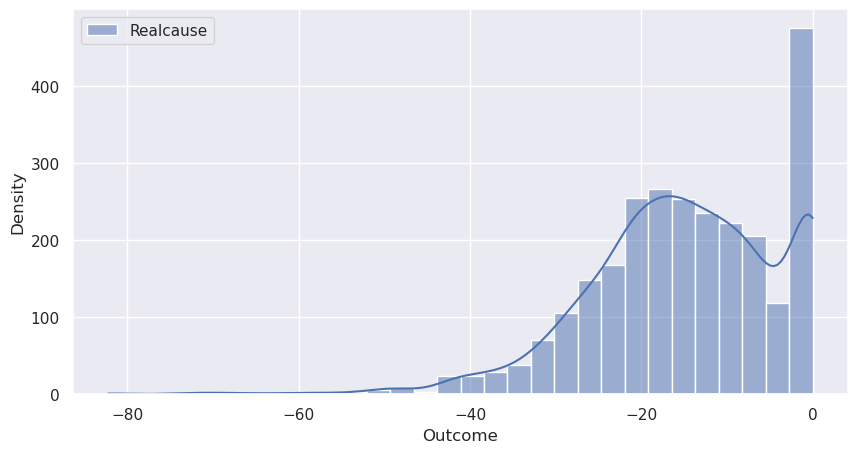

In [152]:
# Print distribution of the outcome variable
plt.figure(figsize=(10, 5))
sns.histplot(df_setting_5['y'], bins=30, kde=True, alpha=0.5, label='Realcause')
plt.xlabel('Outcome')
plt.ylabel('Density')
plt.legend()
plt.show()

## Explore behavior of Realcause 

What happens if we pass in the transformed covariates? 

In [153]:
source_data.head()

,age,education,black,hispanic,married,nodegree,re74,re75,treat,re78
0,37.0,11.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,9930.045898
1,22.0,9.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,3595.894043
2,30.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,24909.449219
3,27.0,11.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,7506.145996
4,33.0,8.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,289.789886


In [154]:
source_data_std = source_data.copy()

In [155]:
# For the columns age, education, re74 and re75 - ensure that the values have mean 0 and standard deviation 1
source_data_std['age'] = (source_data_std['age'] - source_data_std['age'].mean()) / source_data_std['age'].std()
source_data_std['education'] = (source_data_std['education'] - source_data_std['education'].mean()) / source_data_std['education'].std()
source_data_std['re74'] = (source_data_std['re74'] - source_data_std['re74'].mean()) / source_data_std['re74'].std()
source_data_std['re75'] = (source_data_std['re75'] - source_data_std['re75'].mean()) / source_data_std['re75'].std()
source_data_std.head()

,age,education,black,hispanic,married,nodegree,re74,re75,treat,re78
0,0.264214,-0.325650,1.0,0.0,1.0,1.0,-1.328501,-1.286293,1.0,9930.045898
1,-1.164380,-0.980624,0.0,1.0,0.0,1.0,-1.328501,-1.286293,1.0,3595.894043
2,-0.402463,0.001836,1.0,0.0,0.0,0.0,-1.328501,-1.286293,1.0,24909.449219
3,-0.688182,-0.325650,1.0,0.0,0.0,1.0,-1.328501,-1.286293,1.0,7506.145996
4,-0.116744,-1.308110,1.0,0.0,0.0,1.0,-1.328501,-1.286293,1.0,289.789886


In [156]:
w, t, (y0, y1) = rc_model.sample(source_data_std[covariates_col].values, causal_effect_scale = -10.0, untransform = True, ret_counterfactuals=True)
y = y0 * (1 - t) + y1 * t
df = pd.DataFrame(w)
df['t'] = t
df['y'] = y
df['y0'] = y0
df['y1'] = y1
df['ite'] = y1 - y0
ate = (y1 - y0).mean()
print(f'ATE: {ate}')

# Gather this data into a dataframe 
df_setting_6 = df
df_setting_6.head()

ATE: -1108295.0


,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
0,0.264214,-0.325650,1.0,0.0,1.0,1.0,-1.328501,-1.286293,1.0,-2257720.75,0.00,-2257720.75,-2257720.75
1,-1.164380,-0.980624,0.0,1.0,0.0,1.0,-1.328501,-1.286293,0.0,0.00,0.00,-2340792.25,-2340792.25
2,-0.402463,0.001836,1.0,0.0,0.0,0.0,-1.328501,-1.286293,1.0,0.00,-2089827.75,0.00,2089827.75
3,-0.688182,-0.325650,1.0,0.0,0.0,1.0,-1.328501,-1.286293,1.0,-3704691.00,0.00,-3704691.00,-3704691.00
4,-0.116744,-1.308110,1.0,0.0,0.0,1.0,-1.328501,-1.286293,0.0,-4029822.75,-4029822.75,0.00,4029822.75


In [157]:
w, t, (y0, y1) = rc_model.sample(source_data_std[covariates_col].values, causal_effect_scale = -10.0, untransform = False, ret_counterfactuals=True)
y = y0 * (1 - t) + y1 * t
df = pd.DataFrame(w)
df['t'] = t
df['y'] = y
df['y0'] = y0
df['y1'] = y1
df['ite'] = y1 - y0
ate = (y1 - y0).mean()
print(f'ATE: {ate}')

# Gather this data into a dataframe 
df_setting_7 = df
df_setting_7.head()

ATE: -10.0


,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
0,0.000003,-3.307177e-06,0.00001,0.00000,0.00001,0.00001,-0.000013,-0.000013,1.0,-30.561289,-0.0,-30.561289,-30.561289
1,-0.000012,-9.958831e-06,0.00000,0.00001,0.00000,0.00001,-0.000013,-0.000013,0.0,-0.000000,-0.0,-22.429163,-22.429163
2,-0.000004,1.864992e-08,0.00001,0.00000,0.00000,0.00000,-0.000013,-0.000013,1.0,-40.294968,-0.0,-40.294968,-40.294968
3,-0.000007,-3.307177e-06,0.00001,0.00000,0.00000,0.00001,-0.000013,-0.000013,1.0,-37.432304,-0.0,-37.432304,-37.432304
4,-0.000001,-1.328466e-05,0.00001,0.00000,0.00000,0.00001,-0.000013,-0.000013,0.0,-0.000000,-0.0,-71.497200,-71.497200


We have established that the untransform parameter also affects the covariates that are passed back to the user. if untransform = False, then the covariates are again standardized/normalized.

In [158]:
w, t, (y0, y1) = rc_model.sample(source_data[covariates_col].values, causal_effect_scale = -10.0, untransform = True, ret_counterfactuals=True)
y = y0 * (1 - t) + y1 * t
df = pd.DataFrame(w)
df['t'] = t
df['y'] = y
df['y0'] = y0
df['y1'] = y1
df['ite'] = y1 - y0
ate = (y1 - y0).mean()
print(f'ATE: {ate}')

# Gather this data into a dataframe 
df_setting_8 = df
df_setting_8.head()

ATE: -1108295.125


,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
0,37.000000,11.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,3.937936e+05,3.937936e+05
1,22.000000,9.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9.915348e+05,9.915348e+05
2,30.000000,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.000000e+00,0.000000e+00
3,27.000002,11.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00
4,33.000000,8.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,6.753168e+06,6.753168e+06


In [159]:
print(df_setting_6[0].mean())
print(df_setting_6[0].std())
print(df_setting_7[0].mean())
print(df_setting_7[0].std())
print(df_setting_8[0].mean())
print(df_setting_8[0].std())


-1.1408441e-07
1.000002384185791
-1.2185529e-12
1.0155597919947468e-05
34.225796
10.499835014343262


We have also established that Realcause is applying a further scaling and shifting to the covariates - so we should not be starting with the standardized data! 

Let us see what kind of scaling and shifting is applied to the covariates, we want to be able to apply the same to the source data, so that we can compare the results accordingly (to the untransformed data)

In [203]:
from models import preprocess

In [204]:
og_covariates = source_data[covariates_col].values

In [205]:
og_covariates.shape

(2675, 8)

In [206]:
og_cov_df = pd.DataFrame(og_covariates, columns=covariates_col)
og_cov_df.describe()

,age,education,black,hispanic,married,nodegree,re74,re75
count,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000
mean,34.225796,11.994392,0.291589,0.034393,0.819439,0.333084,18230.001953,17850.894531
std,10.499836,3.053559,0.454579,0.182268,0.384722,0.471402,13722.238281,13877.783203
min,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25.000000,10.000000,0.000000,0.000000,1.000000,0.000000,8816.700195,7605.290283
50%,32.000000,12.000000,0.000000,0.000000,1.000000,0.000000,17437.474609,17008.064453
75%,43.500000,14.000000,1.000000,0.000000,1.000000,1.000000,25470.468750,25583.709961
max,55.000000,17.000000,1.000000,1.000000,1.000000,1.000000,137148.687500,156653.234375


In [207]:
og_cov_df.tail()

,age,education,black,hispanic,married,nodegree,re74,re75
2670,47.0,8.0,0.0,0.0,1.0,1.0,44667.363281,33837.097656
2671,32.0,8.0,0.0,0.0,1.0,1.0,47022.402344,67137.093750
2672,47.0,10.0,0.0,0.0,1.0,1.0,48197.964844,47968.113281
2673,54.0,0.0,0.0,1.0,1.0,1.0,49228.539062,44220.968750
2674,40.0,8.0,0.0,0.0,1.0,1.0,50940.937500,55500.000000


In [220]:
standardization = preprocess.Normalize(og_covariates)
std_covariates = standardization.transform(og_covariates)

In [221]:
std_covariates.shape

(2675, 8)

In [222]:
std_cov_df = pd.DataFrame(std_covariates, columns=covariates_col)
std_cov_df.describe()


,age,education,black,hispanic,married,nodegree,re74,re75
count,2675.000000,2675.000000,2675.000000,2.675000e+03,2675.000000,2675.000000,2675.000000,2675.000000
mean,0.000218,0.000077,0.000002,2.195456e-07,0.000005,0.000002,0.116372,0.113952
std,0.000067,0.000019,0.000003,1.163515e-06,0.000002,0.000003,0.087596,0.088589
min,0.000109,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,0.000160,0.000064,0.000000,0.000000e+00,0.000006,0.000000,0.056282,0.048549
50%,0.000204,0.000077,0.000000,0.000000e+00,0.000006,0.000000,0.111313,0.108571
75%,0.000278,0.000089,0.000006,0.000000e+00,0.000006,0.000006,0.162591,0.163314
max,0.000351,0.000109,0.000006,6.383526e-06,0.000006,0.000006,0.875492,1.000000


In [223]:
std_cov_df.head()

,age,education,black,hispanic,married,nodegree,re74,re75
0,0.000236,0.000070,0.000006,0.000000,0.000006,0.000006,0.0,0.0
1,0.000140,0.000057,0.000000,0.000006,0.000000,0.000006,0.0,0.0
2,0.000192,0.000077,0.000006,0.000000,0.000000,0.000000,0.0,0.0
3,0.000172,0.000070,0.000006,0.000000,0.000000,0.000006,0.0,0.0
4,0.000211,0.000051,0.000006,0.000000,0.000000,0.000006,0.0,0.0


In [224]:
og_y = source_data[outcome_col].values
og_y.shape

(2675,)

In [225]:
standardization_y = preprocess.Normalize(og_y)
std_y = standardization_y.transform(og_y)
std_y_df = pd.DataFrame(std_y, columns=[outcome_col])
std_y_df.head()
std_y_df.describe()


,re78
count,2675.000000
mean,0.169198
std,0.129009
min,0.000000
25%,0.076282
50%,0.160366
75%,0.237805
max,1.000000


In [226]:
std_y_df.head()

,re78
0,0.081949
1,0.029676
2,0.205568
3,0.061945
4,0.002392


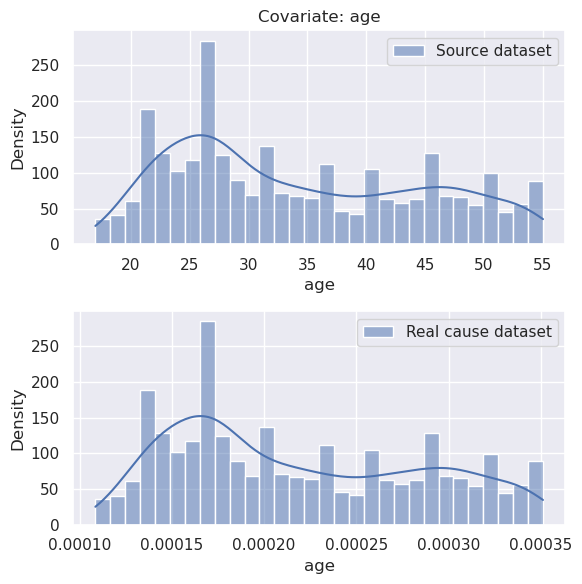

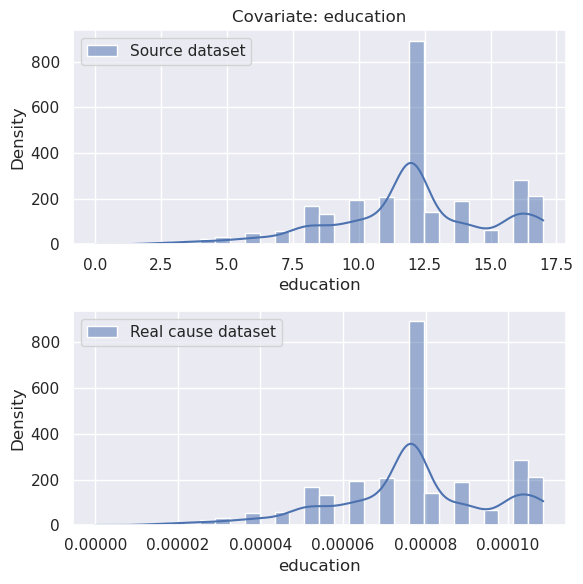

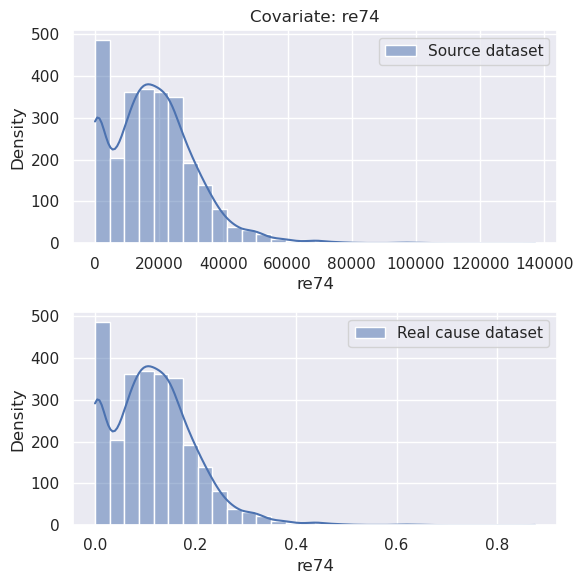

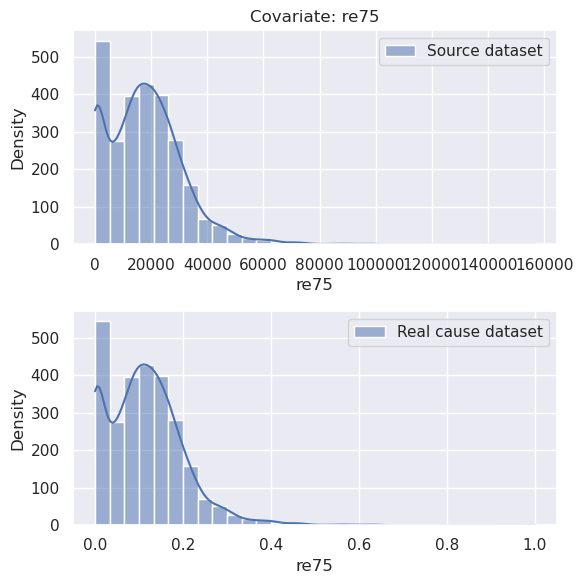

In [227]:
# Plot the shape of the age distribution of the original and standardized data
for col in ['age', 'education', 're74', 're75']: 
    plt.figure(figsize=(6, 6))
    plt.subplot(2, 1, 1)
    sns.histplot(og_cov_df[col], bins=30, kde=True, alpha=0.5, label='Source dataset')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.title(f'Covariate: {col}')
    plt.subplot(2, 1, 2)
    sns.histplot(std_cov_df[col], bins=30, kde=True, alpha=0.5, label='Real cause dataset')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()

In [228]:
df_setting_5.describe()

,0,1,2,3,4,5,6,7,t,y,y0,y1,ite
count,2675.000000,2675.000000,2675.000000,2.675000e+03,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000,2675.000000
mean,0.000348,0.000122,0.000003,3.492770e-07,0.000008,0.000003,0.185137,0.181287,0.065047,-15.038417,-14.935766,-4.935767,10.000000
std,0.000107,0.000031,0.000005,1.851053e-06,0.000004,0.000005,0.139358,0.140937,0.246656,11.371107,11.511563,7.383799,13.793802
min,0.000173,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,-82.245430,-82.245430,-81.361290,-81.361290
25%,0.000254,0.000102,0.000000,0.000000e+00,0.000010,0.000000,0.089539,0.077236,0.000000,-21.652706,-21.652706,-6.959860,0.432420
50%,0.000325,0.000122,0.000000,0.000000e+00,0.000010,0.000000,0.177088,0.172727,0.000000,-14.559839,-14.564732,-3.810593,10.063555
75%,0.000442,0.000142,0.000010,0.000000e+00,0.000010,0.000010,0.258668,0.259818,0.000000,-6.560971,-6.308724,-0.000000,18.136212
max,0.000559,0.000173,0.000010,1.015561e-05,0.000010,0.000010,1.392829,1.590909,1.000000,-0.000000,-0.000000,-0.000000,82.245430


In [229]:
std_cov_df.describe()

,age,education,black,hispanic,married,nodegree,re74,re75
count,2675.000000,2675.000000,2675.000000,2.675000e+03,2675.000000,2675.000000,2675.000000,2675.000000
mean,0.000218,0.000077,0.000002,2.195456e-07,0.000005,0.000002,0.116372,0.113952
std,0.000067,0.000019,0.000003,1.163515e-06,0.000002,0.000003,0.087596,0.088589
min,0.000109,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,0.000160,0.000064,0.000000,0.000000e+00,0.000006,0.000000,0.056282,0.048549
50%,0.000204,0.000077,0.000000,0.000000e+00,0.000006,0.000000,0.111313,0.108571
75%,0.000278,0.000089,0.000006,0.000000e+00,0.000006,0.000006,0.162591,0.163314
max,0.000351,0.000109,0.000006,6.383526e-06,0.000006,0.000006,0.875492,1.000000


This is doing min = 0, max = 1 but across all columns of the covariates! 

In [230]:
df_setting_5['y'].describe()

count    2675.000000
mean      -15.038417
std        11.371107
min       -82.245430
25%       -21.652706
50%       -14.559839
75%        -6.560971
max        -0.000000
Name: y, dtype: float64

In [231]:
std_y_df.describe()

,re78
count,2675.000000
mean,0.169198
std,0.129009
min,0.000000
25%,0.076282
50%,0.160366
75%,0.237805
max,1.000000


How do I get the covariates to the same scale as that applied by Realcause? 